# 3.2 The first model

This notebook builds and evaluates the project's first real model, sentiment and market features
feeding a LightGBM classifier that predicts `label_direction`, the 1-day directional label
`notebooks/modelling/3.0` settled on. It reads `label_and_features_model_ready.parquet`, the corrected
table that notebook produced, and runs everything through the walk-forward harness
`news_sentiment.market.evaluate` was built for, so this iteration's numbers stay directly comparable
to whatever comes after it.

Once a model is fitted and scored, the first question is whether to trust it at all. Feature
importance gets read the same way `3.0` read `momentum_1d`, not as a curiosity about what the model
likes, but as a check for whether something it likes is a leak wearing a feature's name. Anything that
fails that check gets pruned before any tuning happens, since tuning around a leak only teaches the
model to lean on it harder.

What follows is hyperparameter search, wrapped around `evaluate()` rather than folded inside it, and a
closing summary of what changed along the way: what was dropped, what leaked, which hyperparameters
won, and what the next iteration should try that this one didn't.

### 0. Setup

Imports and the one file this notebook reads: `label_and_features_model_ready.parquet`, the corrected
table `3.0` produced, sentiment and market features already joined to the 1-day and 3-day labels.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from news_sentiment.config import PROCESSED_DATA_DIR
from news_sentiment.market.evaluate import day_grouped_splits, evaluate, fit_final_model, feature_importance

pd.set_option("display.max_colwidth", 200)
sns.set_theme(style="whitegrid")

df = pd.read_parquet(PROCESSED_DATA_DIR / "label_and_features_model_ready.parquet")
print("label_and_features_model_ready:", df.shape)
df.head()

2026-08-26 17:00:09.034 | INFO     | news_sentiment.config:<module>:12 - PROJ_ROOT path is: D:\ML\stock-predictor


label_and_features_model_ready: (1976, 38)


,article_id,ticker,timestamp_utc,source,n_total_sents,n_entity_sents,n_ceo_sents,n_boilerplate_sents,entity_share,article_length,...,beta_20d,relative_volume_20d,daily_range_ratio_1d,days_to_earnings,session,news_volume,label_direction_3d,has_ceo_mention,fus_conf_graft_floor_mean_shrunk,fus_trusted_mean_shrunk
0,138796882,TSLA,2025-08-22 08:13:15+00:00,Benzinga,19,1,0,5,0.052632,2611,...,1.705859,0.709182,0.019431,61,pre-market,3,1,False,0.081243,0.081243
1,136476320,TSLA,2025-08-22 10:40:18+00:00,Yahoo,26,4,0,0,0.153846,3256,...,1.705859,0.709182,0.019431,61,pre-market,0,1,False,-0.017239,-0.017239
2,136476576,TSLA,2025-08-22 10:48:06+00:00,Yahoo,20,1,0,11,0.050000,3356,...,1.705859,0.709182,0.019431,61,pre-market,1,1,False,-0.140198,-0.140198
3,138802535,TSLA,2025-08-22 11:10:13+00:00,Benzinga,32,4,0,5,0.125000,4997,...,1.705859,0.709182,0.019431,61,market-hours,13,1,False,-0.168644,-0.168644
4,136476575,TSLA,2025-08-22 11:31:03+00:00,Yahoo,20,2,12,5,0.100000,3352,...,1.705859,0.709182,0.019431,61,pre-market,2,1,True,-0.246081,-0.246081


### 1. Features and label

Splitting `MODEL_FEATURES` into `TEXT_FEATURES` and `MARKET_FEATURES` rather than defining it flat
keeps the door open for running the harness on each half separately later, whether sentiment alone
carries anything on its own, whether the market features do, before crediting the combination. The
identity columns (`article_id`, `ticker`, `timestamp_utc`, `source`) and the other three label columns
(`abnormal_return_1d`, `abnormal_return_3d`, `label_direction_3d`) are excluded from both lists; this
notebook trains on `label_direction`, the 1-day label `3.0` found the real signal in.

`session` is a string, `pre-market` / `market-hours` / `after-hours`, not yet a dtype LightGBM can
split on natively. Fixed next, in 1.1.

In [2]:
TEXT_FEATURES = [
    "n_total_sents", "n_entity_sents", "n_ceo_sents", "n_boilerplate_sents",
    "entity_share", "article_length",
    "fus_conf_graft_floor_mean_shrunk", "fus_conf_graft_floor_median",
    "fus_conf_graft_floor_lead", "fus_conf_graft_floor_top3_pos",
    "fus_conf_graft_floor_top3_neg", "fus_conf_graft_floor_spread",
    "fus_ceo_mean", "has_ceo_mention", "fus_headline", "fus_maxmag",
    "fus_trusted_mean_shrunk", "fus_scorer_gap", "fus_headline_gap", "fus_lead_gap",
]

MARKET_FEATURES = [
    "momentum_1d", "momentum_5d", "momentum_20d", "volatility_20d", "beta_20d",
    "relative_volume_20d", "daily_range_ratio_1d", "days_to_earnings", "session", "news_volume",
]

MODEL_FEATURES = TEXT_FEATURES + MARKET_FEATURES
LABEL = "label_direction"

assert len(MODEL_FEATURES) == len(set(MODEL_FEATURES)), "overlap between TEXT_FEATURES and MARKET_FEATURES"
assert set(MODEL_FEATURES + [LABEL]).issubset(df.columns), "a feature or the label isn't actually in the table"

print(f"TEXT_FEATURES:   {len(TEXT_FEATURES)}")
print(f"MARKET_FEATURES: {len(MARKET_FEATURES)}")
print(f"MODEL_FEATURES:  {len(MODEL_FEATURES)}")
print(f"LABEL:           {LABEL!r}  {df[LABEL].value_counts().to_dict()}")

TEXT_FEATURES:   20
MARKET_FEATURES: 10
MODEL_FEATURES:  30
LABEL:           'label_direction'  {1: 996, -1: 980}


### 1.1 `session` needs a real dtype

`session` is a plain string. Cast to pandas `category` so LightGBM splits on it natively instead of
treating it as ordinary text. Safe to do once, upfront, since the three sessions are a fixed vocabulary
set by market hours, not something derived from this data.

In [3]:
SESSION_CATEGORIES = ["pre-market", "market-hours", "after-hours"]
df["session"] = pd.Categorical(df["session"], categories=SESSION_CATEGORIES)

print("dtype:", df["session"].dtype)
print("categories:", df["session"].cat.categories.tolist())
print("NaN introduced by the cast:", df["session"].isna().sum())
print("value counts:", df["session"].value_counts().to_dict())

dtype: category
categories: ['pre-market', 'market-hours', 'after-hours']
NaN introduced by the cast: 0
value counts: {'pre-market': 774, 'market-hours': 741, 'after-hours': 461}


### 2. Model factory

`evaluate()` needs a zero-argument callable returning a fresh, unfitted model on every call, not a
fitted instance. `model_factory()` below does that: each call returns a new `LGBMClassifier`, never
the same object twice, so no fold can carry state from another.

Hyperparameters here are a deliberate starting point, not a tuned result, chosen conservative given
how little data this is: `num_leaves=7` and `min_child_samples=30` keep trees shallow and leaves
well-populated against fold training sets in the low thousands of rows, `subsample`/`colsample_bytree`
at 0.8 add a little variance reduction on top. Tuning is a later section; this is what the first pass
through `evaluate()` runs with.

Nothing here needs to handle `fus_ceo_mean`'s NaNs or `session`'s categories itself, LightGBM's native
NaN-aware splitting and 1.1's `category` cast already cover both.

In [4]:
def model_factory():
    return lgb.LGBMClassifier(
        objective="binary",
        n_estimators=100,
        num_leaves=7,
        learning_rate=0.05,
        min_child_samples=30,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=-1,
    )


m1, m2 = model_factory(), model_factory()
print("distinct instances per call:", m1 is not m2)
print(m1.get_params())

distinct instances per call: True
{'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 0.8, 'importance_type': 'split', 'learning_rate': 0.05, 'max_depth': -1, 'min_child_samples': 30, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': 100, 'n_jobs': None, 'num_leaves': 7, 'objective': 'binary', 'random_state': 42, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 0.8, 'subsample_for_bin': 200000, 'subsample_freq': 1, 'verbosity': -1}


### 3. Running through evaluate()

Three passes: `MARKET_FEATURES` alone, `TEXT_FEATURES` alone, `MODEL_FEATURES` combined, all against
the same `model_factory` and the same fold boundaries, so the three are directly comparable to each
other and not just to the baseline. `df` is sorted by `timestamp_utc` once here, matching what
`evaluate()` does internally, so the fold indices used in the diagnostics below line up with its own.

Read the raw combined-model numbers first, before anything else.

In [5]:
df = df.sort_values("timestamp_utc").reset_index(drop=True)

result = evaluate(model_factory, df, MODEL_FEATURES, label_col=LABEL)
result_text = evaluate(model_factory, df, TEXT_FEATURES, label_col=LABEL)
result_market = evaluate(model_factory, df, MARKET_FEATURES, label_col=LABEL)

num_cols = result.metrics_df.select_dtypes(include="number").columns
display_df = result.metrics_df.copy()
display_df[num_cols] = display_df[num_cols].round(4)
print(display_df.to_string(index=False))
print()
print(result.aggregate.round(4).to_string())

 fold  n_train  n_test  accuracy  precision  recall     f1    auc  log_loss  brier_score  majority_baseline_accuracy  beats_baseline  mcnemar_p_value  significantly_beats_baseline               train_start                 train_end                test_start                  test_end
    1      271     265    0.7208     0.7132  1.0000 0.8326 0.5752    0.9557       0.2464                      0.6943            True           0.0078                          True 2025-08-22 08:13:15+00:00 2025-09-29 21:11:34+00:00 2025-09-30 03:00:26+00:00 2025-11-26 22:02:55+00:00
    2      536     176    0.3466     0.1364  0.4286 0.2069 0.4168    0.9583       0.3423                      0.1989            True           0.0009                          True 2025-08-22 08:13:15+00:00 2025-11-26 22:02:55+00:00 2025-11-27 09:16:32+00:00 2025-12-31 18:06:21+00:00
    3      712     348    0.4425     0.2661  0.2426 0.2538 0.4334    1.0281       0.3447                      0.3908            True           0.128

Accuracy averages 50.3% across the 5 folds, against a baseline averaging 44.9%, not significant
(`mcnemar_p_value` 0.227). That mean is not the number to trust yet, though: std on accuracy is 14.0
percentage points, larger than most of the differences it's being compared against, and the baseline
itself swings from 19.9% to 69.4% fold to fold, which a genuinely 50/50-labelled corpus should not do.
Something about how these folds are constructed is producing wildly different test conditions, not just
wildly different scores. That is worth understanding before reading anything into the mean.

### 3.1 Fold volume and label balance

`day_grouped_splits` (`news_sentiment/market/evaluate.py`) cuts the corpus into folds by counting
*active days*, not rows: fold 3's test set is defined as "the next 15 active days," and every fold
gets the same day count. That is meant to give every fold a fair, comparable slice. It only works if
active days are roughly interchangeable, carrying a similar number of articles and a similar label mix
regardless of which 15 get picked.

`3.0` section 6 already found they aren't. Only 92 of the 351 days in the corpus span carry any article
at all, empty gaps run as long as 27 days, and the active days aren't scattered evenly, they cluster
into about 13 short bursts near the end of each calendar month, 4-11 days wide, each one carrying
126-191 articles regardless of how wide it is, an artefact of how the Finnhub pull was collected, not a
real pattern in TSLA coverage. If those bursts differ from each other, in size and in which direction
the stock was moving at the time, "the next 15 active days" stops being a fair, comparable slice and
starts being "whichever burst happens to fall there." Checking that directly.

 fold  n_train  n_test  test_active_days  test_articles_per_active_day  train_pos_pct  test_pos_pct
    1      271     265                15                          17.7           56.5          69.4
    2      536     176                15                          11.7           62.9          19.9
    3      712     348                15                          23.2           52.2          39.1
    4     1060     387                15                          25.8           47.9          42.9
    5     1447     529                15                          35.3           46.6          60.9


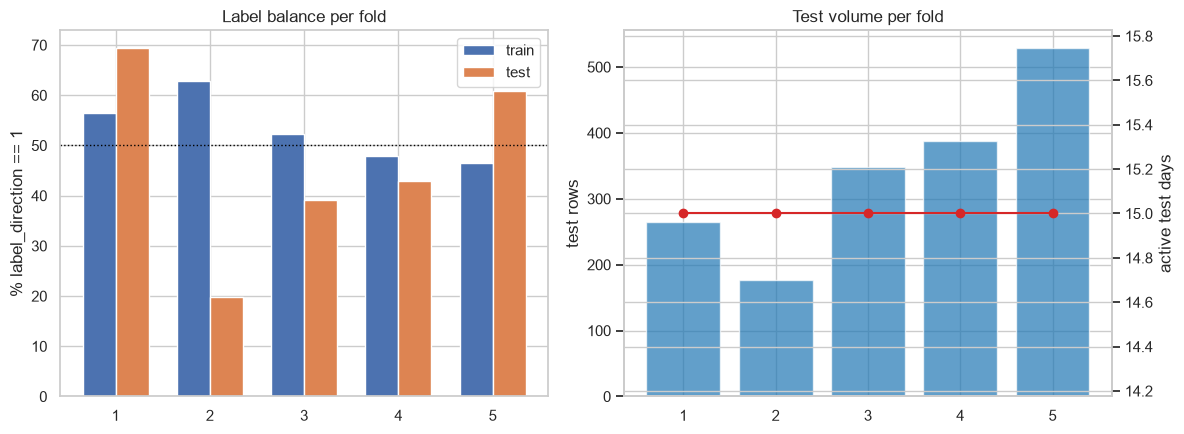

In [6]:
rows = []
for i, (train_mask, test_mask) in enumerate(day_grouped_splits(df["timestamp_utc"], n_splits=5), start=1):
    train_idx = np.flatnonzero(train_mask)
    test_idx = np.flatnonzero(test_mask)
    test_days = df["timestamp_utc"].iloc[test_idx].dt.normalize().nunique()
    rows.append({
        "fold": i,
        "n_train": len(train_idx),
        "n_test": len(test_idx),
        "test_active_days": test_days,
        "test_articles_per_active_day": len(test_idx) / test_days,
        "train_pos_pct": df[LABEL].iloc[train_idx].eq(1).mean() * 100,
        "test_pos_pct": df[LABEL].iloc[test_idx].eq(1).mean() * 100,
    })
vol_df = pd.DataFrame(rows)
print(vol_df.round(1).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = vol_df["fold"]
w = 0.35
axes[0].bar(x - w / 2, vol_df["train_pos_pct"], width=w, label="train")
axes[0].bar(x + w / 2, vol_df["test_pos_pct"], width=w, label="test")
axes[0].axhline(50, color="black", linewidth=1, linestyle=":")
axes[0].set_xticks(x)
axes[0].set_ylabel("% label_direction == 1")
axes[0].set_title("Label balance per fold")
axes[0].legend()

axes[1].bar(x, vol_df["n_test"], color="tab:blue", alpha=0.7)
ax2 = axes[1].twinx()
ax2.plot(x, vol_df["test_active_days"], color="tab:red", marker="o", label="active days")
axes[1].set_xticks(x)
axes[1].set_ylabel("test rows")
ax2.set_ylabel("active test days")
axes[1].set_title("Test volume per fold")
plt.tight_layout()
plt.show()

Confirmed, and worse than expected. Every fold's test window covers exactly 15 active days, by
construction, but that fixed day count carries anywhere from 176 rows (fold 2) to 529 (fold 5),
11.7 to 35.3 articles per active day. 15 active days is not a fixed amount of data, it is however many
articles happened to land in whichever bursts those 15 days touch, and the bursts are not the same
size.

Worth separating two things that look similar in the `n_train`/`n_test` columns but aren't. `n_train`
growing fold to fold, 271 to 536 to 712 to 1060 to 1447, is expected and correct, that's the expanding
walk-forward window doing its job, each fold training on more history than the last. `n_test` varying
176 to 529 is a different matter and not something the split is supposed to allow: every fold's test
set is meant to be a comparable, roughly equal-sized slice, so that accuracy is being compared on a
fair basis fold to fold. `day_grouped_splits` tries to guarantee that by fixing the *day count* at 15,
on the assumption that a fixed number of active days means a roughly fixed amount of test data. The
corpus's burstiness breaks that assumption, not the expanding-window part.

`test_pos_pct` runs 69.4% -> 19.9% -> 39.1% -> 42.9% -> 60.9%, nowhere near the corpus-wide 50.4%/49.6%
split `3.0` measured. That is the second half of the same mechanism: `3.0` section 6 already found
TSLA's climb period ran roughly 65% positive-labelled while the descent period sat close to a coin
flip, one stock, two very different regimes depending on the stretch of the year. The same effect shows
up here at the scale of a single burst: whichever few weeks a fold's test window happens to land on
inherits that stretch's own lean, not the corpus's overall balance.

That breaks what `majority_baseline_accuracy` is supposed to measure. It is the majority class of that
fold's own *training* data, meant to be a roughly stable ~50% reference so that beating it means
something. Instead it swings right along with the same burst-level skew, because a fold's training data
already carries whatever lean the bursts before it had. A fold "beating baseline" here can mean nothing
more than the model's training window happening to lean the same way as the next burst, luck of which
stretch of the year it landed on, not evidence of real skill. That has to be checked directly before
trusting any of this notebook's scores, which is what 3.2 does next.

### 3.2 Is the model learning, or defaulting to something else?

Given how unevenly the label sits fold to fold, the next question is what the model is actually doing
about it. Checking directly, rather than assuming: does its predicted direction track its own training
data's label balance, does it track the test fold's actual direction, or neither.

 fold  train_pos_pct  actual_pos_pct  pred_pos_pct train_pos_dir actual_pos_dir pred_pos_dir
    1           56.5            69.4          97.4      positive       positive     positive
    2           62.9            19.9          62.5      positive       negative     positive
    3           52.2            39.1          35.6      positive       negative     negative
    4           47.9            42.9          20.2      negative       negative     negative
    5           46.6            60.9          93.2      negative       positive     positive

predicted direction matches train's own majority:  3/5
predicted direction matches test's actual majority: 4/5


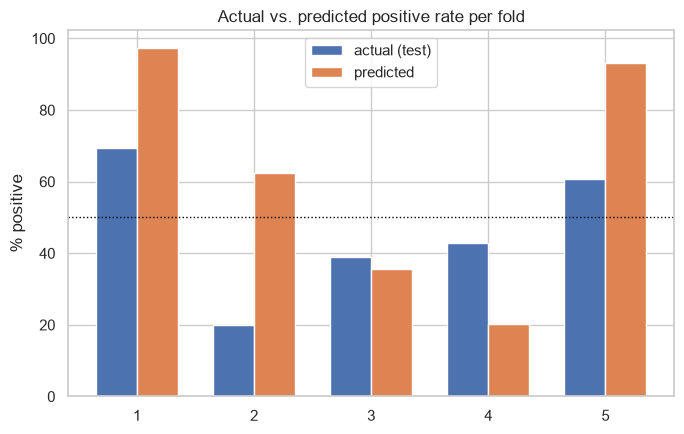

In [7]:
pred_rows = []
for f in result.folds:
    y_pred = pd.Series(f.y_pred)
    actual_pos = df[LABEL].iloc[f.test_idx].eq(1).mean() * 100
    pred_pos = y_pred.eq(1).mean() * 100
    pred_rows.append({"fold": f.fold, "actual_pos_pct": actual_pos, "pred_pos_pct": pred_pos})
pred_df = pd.DataFrame(pred_rows).merge(vol_df[["fold", "train_pos_pct"]], on="fold")

direction = pred_df.copy()
for col in ["train_pos_pct", "actual_pos_pct", "pred_pos_pct"]:
    direction[col.replace("_pct", "_dir")] = np.where(direction[col] > 50, "positive", "negative")
print(direction[["fold", "train_pos_pct", "actual_pos_pct", "pred_pos_pct",
                  "train_pos_dir", "actual_pos_dir", "pred_pos_dir"]].round(1).to_string(index=False))
print()
agrees_train = (direction["pred_pos_dir"] == direction["train_pos_dir"]).sum()
agrees_test = (direction["pred_pos_dir"] == direction["actual_pos_dir"]).sum()
print(f"predicted direction matches train's own majority:  {agrees_train}/5")
print(f"predicted direction matches test's actual majority: {agrees_test}/5")

fig, ax = plt.subplots(figsize=(7, 4.5))
x = pred_df["fold"]
w = 0.35
ax.bar(x - w / 2, pred_df["actual_pos_pct"], width=w, label="actual (test)")
ax.bar(x + w / 2, pred_df["pred_pos_pct"], width=w, label="predicted")
ax.axhline(50, color="black", linewidth=1, linestyle=":")
ax.set_xticks(x)
ax.set_ylabel("% positive")
ax.set_title("Actual vs. predicted positive rate per fold")
ax.legend()
plt.tight_layout()
plt.show()

Not what a "copies its own training balance" story would predict. Folds 3 and 5 are the clean
counter-examples: fold 5 trained on data that was 53.4% *negative*, negative the majority class, yet
the model predicts positive on 93.2% of that fold's test rows, and the test fold really was 60.9%
positive. Fold 3 does the same in the other direction. Predicted direction matches the test fold's
actual majority in 4 of 5 folds, and matches training's own majority in only 3 of 5, so whatever the
model is doing, it is not simply memorising which class its training data leaned toward and repeating
it.

Something else is driving the prediction, then, and the likeliest candidate is whatever the model
leans on hardest, taken up properly in section 4.

Two things keep this from being a "found real skill" result regardless of the cause. First, the model
is never close to calibrated, predicted positive rates run 97%, 93%, 62%, 36%, 20%, always committing
hard to one side, never expressing anything close to uncertainty. Second, 4 correct directions out of 5
folds is weak evidence on its own, under pure chance that or better happens about 19% of the time,
which is exactly why the aggregate `mcnemar_p_value`, 0.227, does not call this significant. Fold 2 is
the clean miss, predicting positive 62.5% of the time against an actual rate of 19.9%, and it alone is
enough to keep the overall result from being trustworthy.

### 3.3 Market vs. text vs. combined

Whether the two feature groups are pulling in the same direction, or whether one is carrying the other,
or neither is doing much and combining them just adds noise. All three ran through identical fold
boundaries above, so the comparison is direct.

 fold  baseline  market   text  combined
    1    0.6943  0.7208 0.5774    0.7208
    2    0.1989  0.3295 0.2841    0.3466
    3    0.3908  0.4483 0.5316    0.4425
    4    0.5711  0.5220 0.5194    0.4625
    5    0.3913  0.5406 0.4896    0.5406

                            market_only  text_only  combined
n_train                        805.2000   805.2000  805.2000
n_test                         341.0000   341.0000  341.0000
accuracy                         0.5122     0.4804    0.5026
precision                        0.4167     0.4820    0.3853
recall                           0.5449     0.5716    0.5336
f1                               0.4478     0.4764    0.4285
auc                              0.4765     0.5136    0.4719
log_loss                         0.9654     0.7758    0.9317
brier_score                      0.3161     0.2853    0.3082
majority_baseline_accuracy       0.4493     0.4493    0.4493
mcnemar_p_value                  0.2203     0.3923    0.2274


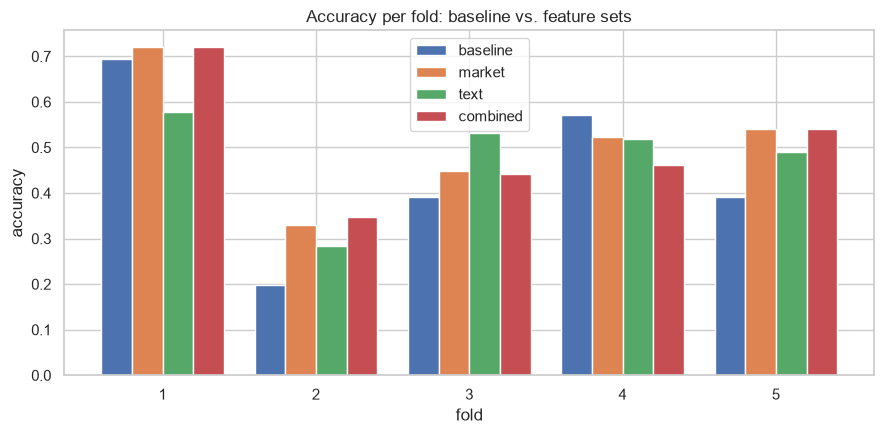

In [8]:
comp_fold = pd.DataFrame({
    "fold": result.metrics_df["fold"],
    "baseline": result.metrics_df["majority_baseline_accuracy"],
    "market": result_market.metrics_df["accuracy"],
    "text": result_text.metrics_df["accuracy"],
    "combined": result.metrics_df["accuracy"],
})
print(comp_fold.round(4).to_string(index=False))
print()

agg_comp = pd.DataFrame({
    "market_only": result_market.aggregate.loc["mean"],
    "text_only": result_text.aggregate.loc["mean"],
    "combined": result.aggregate.loc["mean"],
}).round(4)
print(agg_comp.to_string())

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(comp_fold))
w = 0.2
for i, col in enumerate(["baseline", "market", "text", "combined"]):
    ax.bar(x + (i - 1.5) * w, comp_fold[col], width=w, label=col)
ax.set_xticks(x)
ax.set_xticklabels(comp_fold["fold"])
ax.set_xlabel("fold")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy per fold: baseline vs. feature sets")
ax.legend()
plt.tight_layout()
plt.show()

No clear winner. Mean accuracy: market-only 51.2%, text-only 48.0%, combined 50.3%, all inside a
noise band this small a dataset can't separate. AUC and log loss tell a different story than accuracy
does: text-only has the best AUC (0.514, against 0.477 market and 0.472 combined) and the best log loss
(0.776, against 0.965 market and 0.932 combined), even though its raw accuracy isn't the highest of the
three. None of the three's aggregate McNemar test clears significance (market p=0.220, text p=0.392,
combined p=0.227), so none of them is demonstrably beating the baseline once fold noise is accounted
for; this notebook has not yet produced a model worth trusting.

Combining does not obviously help here. `combined` sits between `market` and `text` on accuracy rather
than above both, and loses to `text` alone on the two metrics that read probability calibration rather
than a hard 0/1 call. With an average of about 805 training rows spread across 30 combined features,
that is a plausible amount of feature count for this little, this noisy a dataset to actually support,
worth carrying into the feature-importance check next rather than assuming combining features can only
help.

Worth reading this comparison next to 3.1 and 3.2, not on its own. Every fold here is scored against
the same burst-skewed baseline 3.1 found, and all three feature sets are driven by the same overconfident,
market-state-heavy model 3.2 found. A gap this small between market, text, and combined could easily be
three slightly different views of the same weak underlying signal riding the same burst noise, rather
than a real ranking of which feature group is better.

### 4. Feature importance

3.2 found the model's predicted direction wasn't simply copying its own training label balance, in two
of five folds it broke from training's majority and matched the test fold's actual direction instead,
and left open what it was leaning on to do that. `feature_importance()` answers it directly: mean and
std of `.feature_importances_` across `result`'s five fold models, on the combined feature set, so
whatever the model leans on hardest is visible rather than guessed at.

This doubles as the leak check the intro promised. Whatever ranks highest gets the same scrutiny `3.0`
section 11 gave `momentum_1d`, since a feature that looks suspiciously load-bearing is what a leak looks
like from this side of the table. One candidate worth watching for going in: rolling market-state
features, momentum, volatility, volume, days-to-earnings, are autocorrelated by nature, a volatile
stretch tends to be followed by another volatile-ish one, none of which requires reading the article. If
the model is leaning on those, this table should show it.

                         feature  importance_mean  importance_std
                     news_volume            123.6       17.681629
                days_to_earnings             80.6       19.885673
             relative_volume_20d             52.8       16.606023
                  volatility_20d             47.2       13.151426
                        beta_20d             35.8       11.989996
                         session             34.8        4.707441
                    momentum_20d             34.4       13.484806
                     momentum_1d             33.6        9.264988
                     momentum_5d             27.6       10.537552
            daily_range_ratio_1d             23.6        7.116179
                  fus_scorer_gap             10.4        5.314132
                  article_length              8.2        6.523803
                    fus_headline              6.6        4.454211
   fus_conf_graft_floor_top3_neg              6.2        2.712932
          

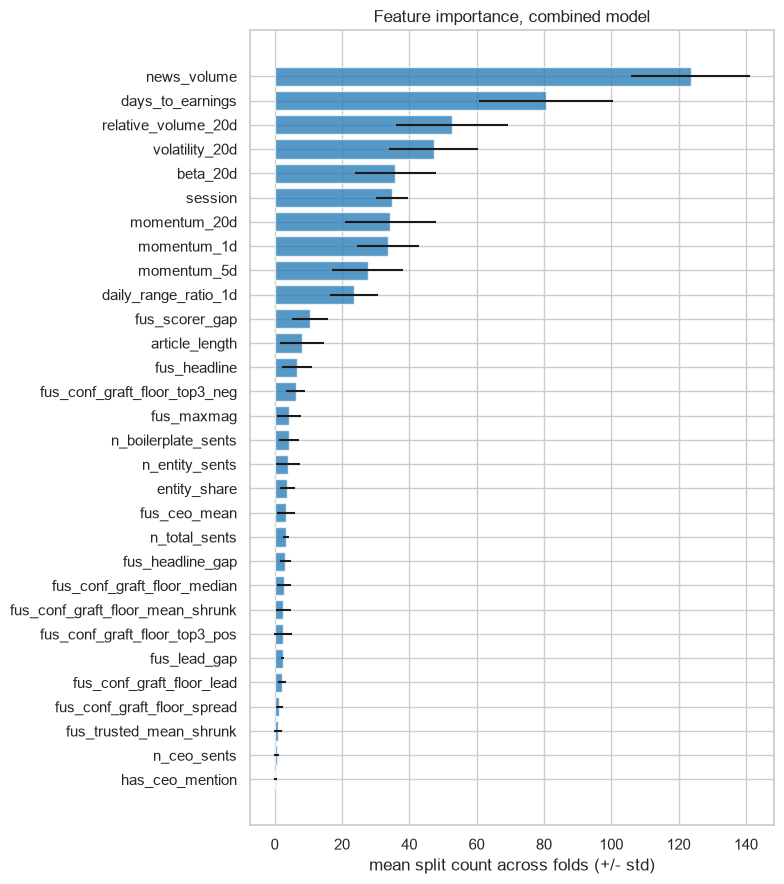

In [9]:
fi = feature_importance(result, MODEL_FEATURES)
print(fi.to_string(index=False))
print()
print("top 5 share of total mean importance:", (fi["importance_mean"].head(5).sum() / fi["importance_mean"].sum()).round(4))

fig, ax = plt.subplots(figsize=(8, 9))
fi_sorted = fi.sort_values("importance_mean")
ax.barh(fi_sorted["feature"], fi_sorted["importance_mean"], xerr=fi_sorted["importance_std"], color="tab:blue", alpha=0.75)
ax.set_xlabel("mean split count across folds (+/- std)")
ax.set_title("Feature importance, combined model")
plt.tight_layout()
plt.show()

The top 10 by mean importance are every market feature this notebook has, in this order:
`news_volume`, `days_to_earnings`, `relative_volume_20d`, `volatility_20d`, `beta_20d`, `session`,
`momentum_20d`, `momentum_1d`, `momentum_5d`, `daily_range_ratio_1d`. `fus_scorer_gap`, the first text
feature, comes in 11th at 10.4, well behind `daily_range_ratio_1d`'s 23.6. The top 5, all market, cover
59.9% of total importance on their own.

That's consistent with the candidate raised above. If the model is picking up a genuine, if weak, echo
of the market's recent state carrying forward into the next few weeks rather than anything from
sentiment, a bank of autocorrelated market features dominating the split counts is exactly what that
would look like, not proof of it on its own, but the shape fits: text features barely register, and the
features that do dominate are precisely the ones with real short-horizon persistence in a financial time
series.

Consistent is not the same as confirmed, though. The two features on top, `news_volume` and
`days_to_earnings`, are the sharpest version of this to test: if either one lets the model tell folds
apart by value alone, that is a leak in the same shape `momentum_1d` was, not just a resemblance.

### 4.1 Are the top two features acting as a fold identifier?

If `news_volume` or `days_to_earnings` let the model tell folds apart by value alone, the same way
`momentum_1d` let a pre-fix row identify its own same-day close, each fold's test window should occupy
a fairly distinct range. Checking directly.

In [10]:
rows = []
for i, (train_mask, test_mask) in enumerate(day_grouped_splits(df["timestamp_utc"], n_splits=5), start=1):
    sub = df.iloc[np.flatnonzero(test_mask)]
    rows.append({
        "fold": i,
        "days_to_earnings_min": sub["days_to_earnings"].min(),
        "days_to_earnings_max": sub["days_to_earnings"].max(),
        "days_to_earnings_mean": sub["days_to_earnings"].mean(),
        "news_volume_min": sub["news_volume"].min(),
        "news_volume_max": sub["news_volume"].max(),
        "news_volume_mean": sub["news_volume"].mean(),
    })
range_df = pd.DataFrame(rows)
print(range_df.round(1).to_string(index=False))

 fold  days_to_earnings_min  days_to_earnings_max  days_to_earnings_mean  news_volume_min  news_volume_max  news_volume_mean
    1                    22                    96                   74.7                0              106              60.8
    2                    28                    62                   37.4                0              103              38.4
    3                     0                    83                   58.4                0              147              57.9
    4                    21                    87                   58.2                0              118              67.1
    5                    21                    85                   62.6                0              149              77.8


Not a clean identifier. `days_to_earnings` covers close to its full [0, 96] range inside every
single fold's test window, and `news_volume` does the same against [0, ~150]. Neither feature can be
memorised as "this value means this fold" the way `momentum_1d` could be traced to a specific same-day
close, so the strongest form of the leak concern doesn't hold up.

That doesn't clear the cluster entirely. A tree doesn't need one feature to be a clean identifier; it
can carve a region out of several overlapping ones at once, days_to_earnings *and* volatility *and*
session together might still fingerprint "roughly this stretch of the year" even though no single
feature does it alone. This section moves the concern from "confirmed leak" to "unresolved, still
plausible," not to "cleared." Nothing is being pruned on the strength of this alone, the same standard
`3.0` held `momentum_1d` to before treating it as settled.

One more caveat before trusting the ranking itself: LightGBM's default importance is a split count, how
often a feature got used, not how much it actually helped. Continuous features with many possible split
points, which most of the market cluster are, get more chances to be picked than a feature like
`fus_ceo_mean`, which is NaN on half the corpus and correlated with several sibling `fus_` columns
competing for the same splits. Ranking near the bottom here is not the same claim as carrying no signal;
`3.3` already found the opposite for text on AUC and log loss despite this ranking. Both readings stand
side by side, not resolved into one.

### 4.2 Do several market features together fingerprint the period?

A tree can chain conditions across several features at once, `momentum_20d > 0.03` AND
`volatility_20d < 0.02` AND `days_to_earnings` in `[20, 40]`, not just one. Each condition is a range on
a single feature; stacked together they define a region, a combination of ranges across features at
once. 4.1 found no single feature's range was narrow enough on its own to give away which fold a row is
from. A region built from several features together could still do it, even though no one feature alone
does, a multi-dimensional fingerprint rather than a single threshold.

Testing that directly rather than reasoning about it: forget `label_direction` for a moment, and ask a
different, cleaner question, given only `MARKET_FEATURES`, can a classifier guess which of the 5 folds
a row belongs to. If it can, well above the 20% chance floor for 5 classes, the fingerprint is real.

In [11]:
fold_id = np.zeros(len(df), dtype=int)
for i, (train_mask, test_mask) in enumerate(day_grouped_splits(df["timestamp_utc"], n_splits=5), start=1):
    fold_id[np.flatnonzero(test_mask)] = i

# fold_id == 0 is the warm-up stretch that only ever appears in fold 1's training set, never in any
# fold's test window, so it has no period label to predict and is excluded.
mask = fold_id > 0
X = df.loc[mask, MARKET_FEATURES]
y = fold_id[mask]
print("rows excluded (never in a test window):", (~mask).sum())
print("rows used:", mask.sum(), " per-fold counts:", pd.Series(y).value_counts().sort_index().to_dict())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

fold_id_clf = lgb.LGBMClassifier(objective="multiclass", num_class=5, n_estimators=200, num_leaves=15,
                                  learning_rate=0.05, random_state=42, verbosity=-1)
fold_id_clf.fit(X_train, y_train)
fold_id_pred = fold_id_clf.predict(X_test)
fold_id_acc = accuracy_score(y_test, fold_id_pred)

print(f"\nfold-id classifier accuracy: {fold_id_acc:.4f}   chance baseline (5 classes): {1/5:.4f}")

fp_importance = pd.Series(fold_id_clf.feature_importances_, index=MARKET_FEATURES).sort_values(ascending=False)
print()
print(fp_importance)

rows excluded (never in a test window): 271
rows used: 1705  per-fold counts: {1: 265, 2: 176, 3: 348, 4: 387, 5: 529}

fold-id classifier accuracy: 0.9961   chance baseline (5 classes): 0.2000

momentum_20d            1998
momentum_1d             1483
news_volume             1235
momentum_5d             1156
volatility_20d          1129
days_to_earnings        1007
relative_volume_20d      807
beta_20d                 737
session                  383
daily_range_ratio_1d     250
dtype: int32


Resolved: yes, decisively. A classifier given nothing but `MARKET_FEATURES` identifies which fold's
test window a row belongs to with 99.6% accuracy, against a 20% chance baseline for 5 classes. Several
market features together are an almost perfect fingerprint for "roughly this stretch of the year."

Worth being precise about what that does and doesn't mean before reacting to it. This is not the same
kind of leak `momentum_1d` was, no feature here is peeking at information that did not exist yet.
It is closer to the opposite: `days_to_earnings` moves in a near-deterministic sawtooth against the
calendar, and momentum, volatility, and volume are all genuinely autocorrelated, so of course a bank of
slow-moving, calendar-correlated features can tell apart five non-overlapping calendar blocks almost
perfectly. That part is expected once stated plainly, not a bug.

What it does confirm is the practical concern 4.1 left open. If the model can locate "roughly this
stretch of the year" this precisely from market state alone, it has an easy substitute available for
the question this notebook actually wants answered. Instead of asking "does this article's sentiment
predict the market's move," it can get most of the way to a good training score by asking something
much cheaper: "do this row's recent market features resemble a period that tended to go up, or one that
tended to go down." The feature ranking here backs that reading, `momentum_20d`, `momentum_1d`, and
`news_volume` top this classifier's list, the same names that top `4`'s importance table for the actual
model. Consistent with, though still not proof of, 3.2's finding that predictions were extreme and
sometimes tracked the test fold's actual direction rather than training's own label balance: a model
with an easy way to recognise which period it is looking at, and what that period tended to do, does
not need to read the article to look like it is doing something clever.

### 5. Summary of findings

What sections 3 through 4.2 actually showed, gathered in one place.

The raw result looked like an unremarkable, slightly-noisy first attempt: 50.3% accuracy, not
significant. What it actually was, was unstable in a way the headline number hid, traced back to
`day_grouped_splits` grouping by day count on a corpus that publishes in uneven bursts rather than
continuously, which left every fold testing on a different-sized, differently-skewed slice of the year.
Checking what the model was doing inside that instability ruled out the easy explanation, it wasn't
simply repeating its own training label balance, which meant something else was driving its
predictions. Feature importance pointed at market state rather than sentiment, and by the end of the
section that trail resolved cleanly: several market features together can identify which few weeks of
the corpus a row is from with 99.6% accuracy, handing the model an easy substitute for reading the
article at all. The detail behind each step is below.

**The raw score.** The combined model averages 50.3% accuracy across the 5 folds, std 14.0 percentage
points, against a baseline averaging 44.9%. Not significant (`mcnemar_p_value` 0.227). Nothing in this
notebook has yet demonstrated a model with real skill.

**Why the folds swing so hard.** `day_grouped_splits` divides the corpus by active-day count, not row
count. `n_train` growing fold to fold (271 to 1447) is the expanding walk-forward window working as
intended, not part of the problem. `n_test` is the part that should have stayed roughly constant and
didn't: the corpus is bursty, 92 of 351 days active, gaps up to 27 days, coverage clustered into about
13 short bursts of 4-11 days each, carrying 126-191 articles per burst regardless of width, so "the next
15 active days" lands on a different-sized, differently-skewed burst every fold. Test row counts ran 176
to 529, and test-set label balance ran 19.9% to 69.4% positive, against a corpus-wide 50.4%/49.6%.
`majority_baseline_accuracy`, which is supposed to be a stable ~50% reference, swings with it, because
it inherits whatever lean the bursts already seen carried.

**What the model is actually doing.** Checked directly: the model's predicted direction is always
extreme, 97%, 93%, 62%, 36%, 20% positive across the five folds, never close to calibrated. It is not
simply copying its own training label balance either: in two of five folds (3 and 5) its predicted
direction disagreed with training's own majority class and instead matched the test fold's actual
direction, 4 of 5 folds overall. That is weak evidence of some real, if faint, forward-looking signal,
but 5 folds cannot separate that from luck, and it is not significant in aggregate (`mcnemar_p_value`
0.227). Fold 2 is the clean miss, predicting positive 62.5% of the time against an actual rate of 19.9%.

**Market vs. text vs. combined.** Mean accuracy: market-only 51.2%, text-only 48.0%, combined 50.3%,
none separable from noise, none significant against baseline (p=0.220 / 0.392 / 0.227). Text-only has
the best AUC (0.514) and lowest log loss (0.776) of the three despite the lowest raw accuracy.

**Feature importance, and why market dominates.** Every one of the top 10 features by mean split count
is a market feature, `news_volume` and `days_to_earnings` first and second; the first text feature,
`fus_scorer_gap`, ranks 11th. The top 5 account for 59.9% of total importance. Sentiment's near-zero raw
correlation with the label, 0.033 to 0.046 depending on the variant (`3.0`), gives a tree very little to
build a useful split on; market features are continuous, offering far more split points to try, and
several of them, momentum, volatility, are genuinely autocorrelated, a volatile stretch tends to be
followed by another volatile-ish one. Loss-minimising boosting gravitates to whichever feature reduces
training loss most at each step, so the market cluster wins that competition structurally, not because
sentiment was tried and discarded.

**The regime-fingerprint check.** No single market feature acts as a clean fold identifier, both
`news_volume` and `days_to_earnings` span close to their full range inside every fold (4.1). But several
of them together do: an auxiliary classifier given only `MARKET_FEATURES` identifies which fold's test
window a row belongs to with 99.6% accuracy against a 20% chance baseline (4.2), and the features it
leans on hardest, `momentum_20d`, `momentum_1d`, `news_volume`, are the same ones topping the primary
model's own importance table. Expected once stated plainly, calendar-correlated features like
`days_to_earnings` and autocorrelated ones like momentum and volatility should be able to tell
non-overlapping calendar blocks apart, not itself a leak in the same sense `momentum_1d` was. But it
does confirm the practical concern: the primary model has ample means to substitute "which period is
this, and what did that period tend to do" for anything resembling a per-article read, which is
consistent with 3.2's finding of extreme, overconfident predictions that sometimes tracked the test
fold's actual direction rather than training's own label balance.

### 6. The decision

This notebook has not produced a model worth trusting. Accuracy is not significant against baseline,
and the strongest available explanation for what edge it does show is regime-fingerprinting through
market features, not a genuine read of the article.

### 6.1 No hyperparameter tuning

Two findings break fold-to-fold comparability: `3.1`'s test volume and label balance swing hard fold to
fold (176-529 rows, 19.9-69.4% positive), and `4.2` showed market features alone identify which fold a
row is from with 99.6% accuracy. Tuning against scores shaped by both would mean fitting noise and
getting better at exploiting the fingerprint, not at reading the article. That capacity is better spent
fixing those two problems first.

### 6.2 Fold-splitting fix for the next iteration

`3.1`'s root cause was `day_grouped_splits` grouping by active-day count, the wrong proxy for "amount
of test data" on a bursty corpus. Options considered, in priority order:

- **Recommended now: split by row count instead of day count.** Still snap fold boundaries to whole
  days, so no day is ever divided across train and test, just size each fold by rows rather than days.
  Directly targets the mechanism `3.1` found, cheap, no new data needed.
- **Recommended now: size-weighted `.aggregate`.** A 176-row fold and a 529-row fold currently count
  equally toward the mean; weighting by fold size is a one-line change that makes the aggregate more
  honest, alongside the row-count fix above.
- **Optional side test: more folds (`n_splits`).** Worth trying on top of the two changes above, to
  see whether it yields any further improvement, but not load-bearing on its own. With only ~13 bursts
  in the corpus, more folds mostly means each one covers fewer bursts, not a smoother average.
- **Last resort: refetch a less bursty corpus.** The most complete fix, since the burstiness is a
  Finnhub collection artefact (`3.0` section 6), not a fact about TSLA, but the most expensive by far,
  re-scraping and re-running the full text pipeline. Marked necessary only if the next iteration, with
  row-count splitting and weighted aggregation in place, still shows no improvement.

One limit on any of this: `3.0` also found TSLA traded in genuine multi-week trending regimes this
year, the climb, the descent, which is a real property of the stock's own history, not just a sampling
artefact. Better splitting fixes the row-count and burst-alignment problem; it doesn't remove
regime-driven label skew entirely.

### 6.3 Getting sentiment to actually contribute, next iteration

Four angles, in priority order.

- **Recommended: strengthen sentiment at the source, two independent changes.** `3.0` section 12 already
  named both, left unbuilt. Try each on its own, not as a combined pipeline:
  - **Relative sentiment.** Subtract the day's mean sentiment from an article's own score, so the model
    reads "more positive than the day's tone" rather than a raw score competing with everything else
    published that day. Keeps the current one-row-per-article table.
  - **Day-level aggregation.** Collapse each active day's articles into one row, mean sentiment, article
    count, spread, predicting that day's return, rather than one row per article predicting a move the
    rest of that day's coverage also contributed to. Changes the prediction unit, a bigger change than
    the one above.

- **Not ideal, but worth testing: ensemble market and text apart instead of one combined model.**
  Splitting them into two separately-fit models and blending the predictions would stop them competing
  for splits, but market and text arguably should complement each other, a genuinely good day, positive
  market state *and* positive sentiment together, may be a real, stronger signal than either alone,
  which a combined tree can capture and two independent models blended after the fact cannot. Not
  recommended as the default for that reason, but cheap enough to try and compare against the combined
  model to see whether it yields any improvement.

- **Diagnostic, cheap to run alongside either: drop the confirmed fingerprint cluster.** Refit with
  `momentum_20d`, `momentum_1d`, `news_volume`, the features `4.2`'s classifier leaned on hardest,
  removed, and check whether accuracy collapses toward baseline or holds up. Tells you how much of this
  iteration's result was regime-fingerprinting versus a real, if small, market contribution worth
  keeping, informing how much further any of the above needs to go.

- **Heavier, deferred.** Re-engineering market features against their own rolling baseline rather than
  raw level, to reduce their calendar-correlation directly, or LightGBM's `interaction_constraints` /
  `monotone_constraints` to cap how much a single feature group can drive a split. Not proposed for the
  next iteration, worth trying only if the above doesn't move the result.

### 6.4 Recommended sequence across the next iterations

`6.1`-`6.3` list options; this orders them, since fixing the measuring stick has to come before using
it to compare candidate fixes.

**Iteration 2: fix the harness, not the model.** Row-count-based splitting and size-weighted
`.aggregate` (`6.2`), rerun this same combined model unchanged through the fixed harness, and run the
fingerprint-cluster ablation (`6.3`, dropping `momentum_20d`, `momentum_1d`, `news_volume`) alongside it
as a diagnostic. Also try more folds (`6.2`) as a cheap side test on top of the row-count fix, not
load-bearing on its own, worth a quick check now that it's riding along with a real change rather than
being tried in isolation. Nothing about the model or features changes here, the point is a trustworthy
set of fold scores and a real read on how much of this iteration's result was regime-fingerprinting.
Every later comparison depends on it being done first: comparing candidate fixes against an unreliable
harness would just repeat this iteration's mistake one level up.

**Iteration 3: test the sentiment-source and combination questions, through the fixed harness.**
Relative sentiment and day-level aggregation (`6.3`), tried independently as two separate runs, plus the
market/text ensemble-vs-combined comparison (`6.3`). Four candidate configurations in total against the
iteration-2 baseline, all scored the same way, so the comparison is meaningful for the first time this
project has one.

**Only if iteration 3 still underperforms: the heavier options, in order.** Market-feature
re-engineering against their own rolling baseline first (`6.3`): it attacks the mechanism `4.2` found
directly, and is directly verifiable, rerun `4.2`'s own fold-id classifier against the re-engineered
features and check whether 99.6% actually drops. LightGBM's `interaction_constraints` /
`monotone_constraints` (`6.3`) second, only if re-engineering alone doesn't move it enough: a model-level
restriction on top of the features rather than a fix to what they represent, and it needs a constraint
structure decided in advance, better informed by knowing how far re-engineering alone got. Refetching a
less bursty corpus (`6.2`) stays the true last resort, most expensive of everything on this list, only
justified once the cheaper options above have had a real chance to work.

**Hyperparameter tuning re-enters after that**, once a feature and label recipe exists that's actually
worth tuning, not before. `6.1`'s reasoning for skipping it this iteration applies just as much to
iteration 2 and 3: tune only once the thing being tuned is trustworthy.